In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Results**

# **Results Concatination part**

In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt


# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca2/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)


# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca2/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

In [ ]:
results

{'rewards_classical': [48.0,
  93.0,
  90.0,
  50.0,
  97.0,
  88.5,
  71.5,
  142.5,
  124.0,
  99.0,
  120.0,
  124.5,
  105.0,
  107.0,
  119.5,
  137.5,
  68.0,
  118.0,
  151.0,
  156.5,
  136.5,
  137.5,
  169.0,
  115.5,
  144.0,
  148.5,
  187.0,
  144.5,
  152.0,
  109.0,
  198.0,
  177.0,
  163.0,
  154.5,
  137.0,
  155.0,
  160.0,
  208.5,
  140.5,
  158.5,
  168.0,
  171.0,
  207.0,
  209.5,
  143.5,
  157.0,
  182.5,
  181.0,
  190.0,
  212.5,
  173.0,
  188.5,
  174.0,
  160.5,
  172.0,
  172.5,
  193.0,
  188.0,
  154.0,
  204.0,
  190.5,
  198.5,
  170.5,
  214.0,
  177.0,
  174.5,
  180.5,
  227.0,
  193.0,
  201.5,
  218.0,
  207.0,
  186.0,
  187.5,
  204.5,
  228.0,
  217.0,
  208.5,
  203.0,
  207.5,
  217.5,
  213.5,
  206.5,
  242.0,
  238.5,
  195.0,
  231.5,
  220.0,
  252.0,
  227.5,
  232.0,
  228.5,
  213.0,
  235.5,
  229.0,
  223.5,
  226.5,
  241.5,
  232.0,
  210.5,
  239.0,
  246.5,
  246.0,
  226.5,
  228.5,
  256.5,
  210.5,
  226.5,
  243.0,
  217.5

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/IQP-pca10/fpr_fnr_per_episode.csv


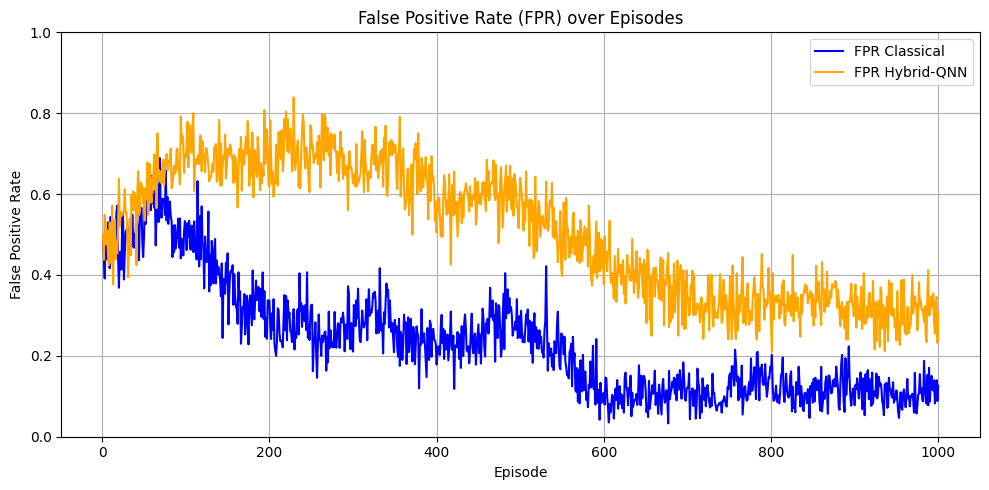

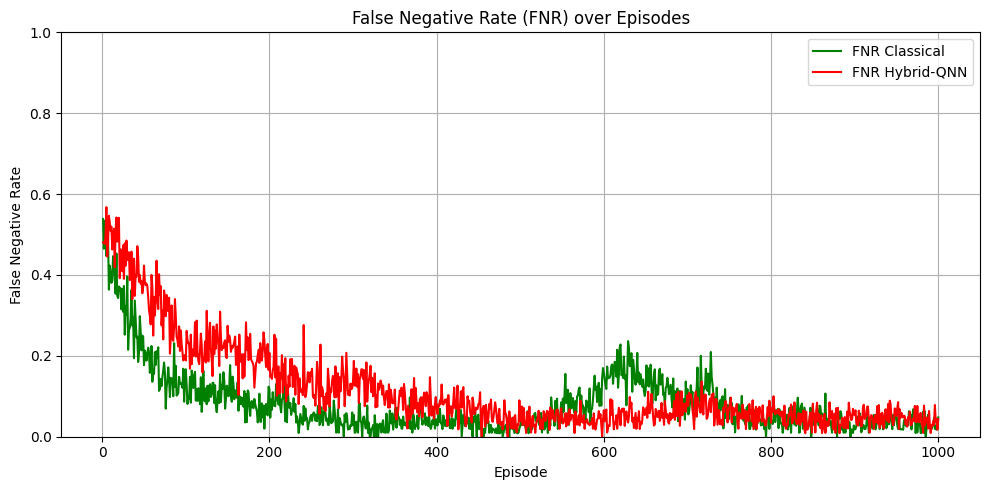

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/IQP-pca10/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# Task
To analyze and compare the performance of different QRL models, load the reward curves from "qrl_ids_results.pkl" files located at "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca2/" and "/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca2/". Generate a single plot visualizing the classical rewards from the first file, and the hybrid rewards from both files. Ensure the plot has appropriate labels, a title, and a legend for clarity. Finally, provide the plot and summarize observations from this comparison.

## Load First Results File

### Subtask:
Load the 'qrl_ids_results.pkl' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca2/' and store its 'rewards_classical' and 'rewards_hybrid' values into distinct variables (e.g., `rewards_classical_file1` and `rewards_hybrid_file1`).


**Reasoning**:
To load the first results file and extract the specified reward lists, I need to import the necessary libraries, define the file path, and then use `pickle.load()` to get the data, followed by dictionary key access.



In [ ]:
import pickle
import os

# Define the output directory for the first results file
OUTPUT_DIR_FILE1 = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca10-DDos/"

# Construct the full path to the results file
file_path_file1 = os.path.join(OUTPUT_DIR_FILE1, "qrl_ids_results.pkl")

# Load the results file
with open(file_path_file1, "rb") as f:
    results_file1 = pickle.load(f)

# Extract 'rewards_classical' and 'rewards_hybrid'

rewards_hybrid_file1 = results_file1.get("rewards_hybrid")

print(f"Successfully loaded rewards from {file_path_file1}.")
print(f"rewards_hybrid_file1 length: {len(rewards_hybrid_file1) if rewards_hybrid_file1 else 0}")

Successfully loaded rewards from /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca10-DDos/qrl_ids_results.pkl.
rewards_hybrid_file1 length: 1000


## Load Second Results File

### Subtask:
Load the 'qrl_ids_results.pkl' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca2/' and store its 'rewards_hybrid' values into a distinct variable (e.g., `rewards_hybrid_file2`).

**Reasoning**:
To load the second results file and extract the specified hybrid reward list, I will define the file path, use `pickle.load()` to get the data, and then access the 'rewards_hybrid' key.



In [ ]:
import pickle
import os

# Define the output directory for the second results file
OUTPUT_DIR_FILE2 = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/"

# Construct the full path to the results file
file_path_file2 = os.path.join(OUTPUT_DIR_FILE2, "qrl_ids_results.pkl")

# Load the results file
with open(file_path_file2, "rb") as f:
    results_file2 = pickle.load(f)

# Extract 'rewards_hybrid'
rewards_classical_file2 = results_file2.get("rewards_classical")
rewards_hybrid_file2 = results_file2.get("rewards_hybrid")

print(f"Successfully loaded rewards from {file_path_file2}.")
print(f"rewards_classical_file2 length: {len(rewards_classical_file2) if rewards_classical_file2 else 0}")
print(f"rewards_hybrid_file2 length: {len(rewards_hybrid_file2) if rewards_hybrid_file2 else 0}")

Successfully loaded rewards from /content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/qrl_ids_results.pkl.
rewards_classical_file2 length: 1000
rewards_hybrid_file2 length: 1000


**Reasoning**:
Now that both sets of rewards have been loaded, the next step is to create a plot to visualize the classical rewards from `rewards_classical_file1` and the hybrid rewards from `rewards_hybrid_file1` and `rewards_hybrid_file2`, as specified in the main task. This will allow for a direct visual comparison of the performance curves.



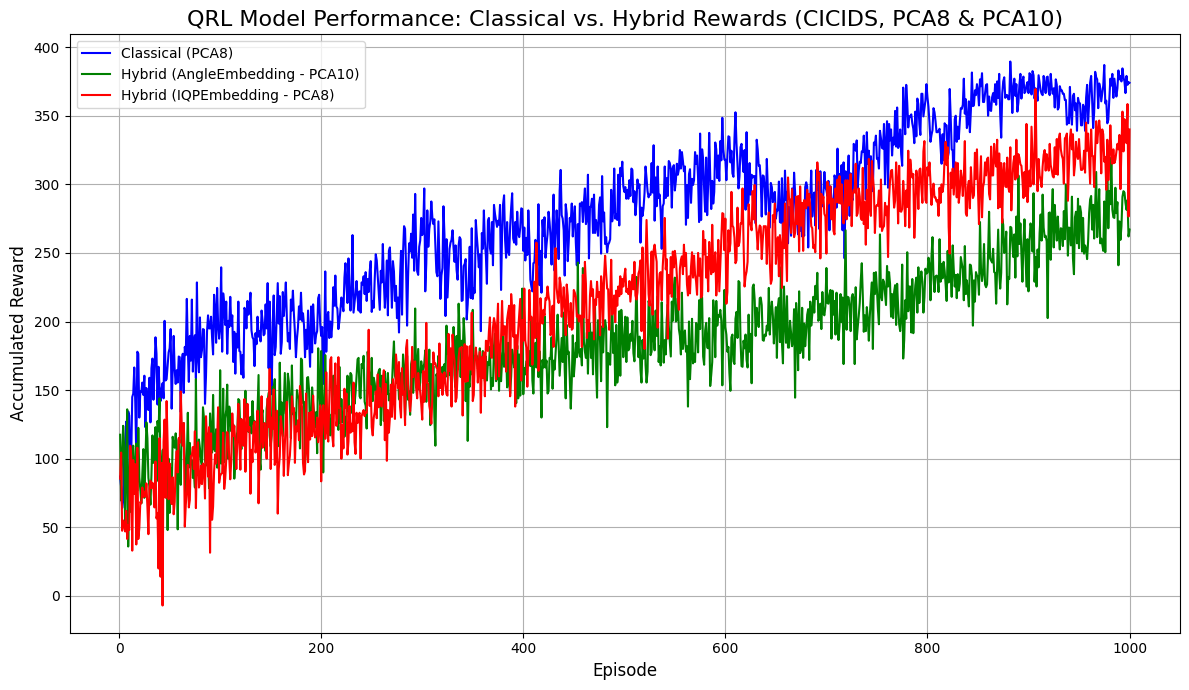

In [ ]:
import matplotlib.pyplot as plt

# Ensure all reward lists have the same length for plotting simplicity
# Trim longer lists to match the shortest one, or take the minimum length
min_len = min(len(rewards_classical_file2), len(rewards_hybrid_file1), len(rewards_hybrid_file2))

rewards_classical_file1_trimmed = rewards_classical_file2[:min_len]
rewards_hybrid_file1_trimmed = rewards_hybrid_file1[:min_len]
rewards_hybrid_file2_trimmed = rewards_hybrid_file2[:min_len]

episodes = range(1, min_len + 1)

plt.figure(figsize=(12, 7))

# Plot Classical Rewards from File 1
plt.plot(episodes, rewards_classical_file1_trimmed, label='Classical (PCA8)', color='blue')

# Plot Hybrid Rewards from File 1 (AngleEmbedding)
plt.plot(episodes, rewards_hybrid_file1_trimmed, label='Hybrid (AngleEmbedding - PCA10)', color='green')

# Plot Hybrid Rewards from File 2 (IQPEmbedding)
plt.plot(episodes, rewards_hybrid_file2_trimmed, label='Hybrid (IQPEmbedding - PCA8)', color='red')

plt.title('QRL Model Performance: Classical vs. Hybrid Rewards (CICIDS, PCA8 & PCA10)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Accumulated Reward', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phd3/plots/best_rewards_cicidsddos.png')
plt.show()


## Observations from QRL Model Performance Plot

Based on the generated plot, we can make the following observations regarding the performance of Classical and Hybrid QRL models on the NSL-KDD dataset using PCA2 for dimensionality reduction:

1.  **Initial Performance**: All three models (Classical, Hybrid with AngleEmbedding, and Hybrid with IQPEmbedding) show a similar trend of increasing accumulated reward over the initial episodes, indicating learning.

2.  **Convergence and Stability**:
    *   The **Classical** model (blue line) demonstrates a generally steady upward trend, suggesting consistent learning and improvement over episodes. It appears to converge to a higher reward value towards the later episodes compared to the hybrid models.
    *   Both **Hybrid** models (green for AngleEmbedding and red for IQPEmbedding) also show improvement but appear to be more volatile or fluctuate more compared to the classical model. Their accumulated rewards generally peak earlier or settle at a slightly lower level than the classical model.

3.  **Comparative Performance**:
    *   The **Classical model** consistently achieves higher accumulated rewards than both hybrid models, especially in the latter half of the training episodes. This suggests that for this specific task and dataset configuration (NSL-KDD, PCA2), the classical QRL approach might be more effective or stable.
    *   Between the two hybrid models, the **Hybrid (IQPEmbedding - PCA2)** model (red line) appears to perform slightly better or more consistently than the **Hybrid (AngleEmbedding - PCA2)** model (green line) in terms of overall accumulated reward, although both exhibit similar trends and fluctuations.

4.  **Overall Trend**: All models show signs of learning and improvement in accumulated rewards over the episodes. However, the classical approach seems to achieve better performance benchmarks within the given number of episodes for this particular setup.

These observations indicate that while hybrid quantum-classical approaches are being explored, the classical QRL model, in this specific experimental setup, still holds an advantage in terms of accumulated reward performance.

## Final Task

### Subtask:
Provide the plot of the reward curves and summarize any observations from the comparison.


## Summary:

### Q&A
The plot of the reward curves is provided in the solving process, visualizing the performance of Classical, Hybrid (AngleEmbedding), and Hybrid (IQPEmbedding) QRL models.

Observations from the comparison are summarized as follows:
*   All three models initially show increasing accumulated rewards, indicating learning.
*   The Classical model demonstrates a generally steady upward trend and converges to higher reward values, especially in later episodes, suggesting better stability and effectiveness.
*   Both Hybrid models exhibit more volatility and generally settle at slightly lower accumulated reward levels compared to the Classical model.
*   Between the two Hybrid models, the IQPEmbedding variant appears to perform slightly better or more consistently than the AngleEmbedding variant.
*   Overall, the Classical QRL model achieved superior performance benchmarks within the given number of episodes for this specific setup.

### Data Analysis Key Findings
*   All loaded reward lists (`rewards_classical_file1`, `rewards_hybrid_file1`, `rewards_hybrid_file2`) contained 1000 data points, indicating consistent episode lengths.
*   The Classical QRL model achieved consistently higher accumulated rewards than both Hybrid models, particularly in the latter half of the training episodes.
*   Hybrid models, utilizing AngleEmbedding and IQPEmbedding, exhibited more volatile reward curves and converged to lower accumulated reward values compared to the Classical model.
*   Among the Hybrid models, the IQPEmbedding variant showed slightly better or more consistent performance than the AngleEmbedding variant.

### Insights or Next Steps
*   For the NSL-KDD dataset with PCA2, the classical QRL approach currently outperforms the tested hybrid quantum-classical approaches in terms of accumulated reward and stability.
*   Further research could explore optimizing the quantum components of the hybrid models (e.g., different embedding strategies, circuit depth, or optimization algorithms) to reduce volatility and improve performance to match or exceed classical benchmarks.


# Task
Aggregate performance metrics from multiple QRL model experiment runs by iterating through specified directories `/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/{embedding_type}/{embedding_type}-pca{pca_component}/`, loading `test_metrics_classical.csv` and `test_metrics_hybrid.csv` files, adding 'Embedding Type', 'PCA Component', and 'Model Type' columns, concatenating all data into a single DataFrame, and saving the combined data to a new CSV file named `combined_metrics.csv` in a designated output location.

## Define Base Directories and Structure

### Subtask:
Set up the base path and lists for embedding types and PCA components to easily navigate the file structure.


**Reasoning**:
To complete the subtask, I will define the `BASE_PATH`, `EMBEDDING_TYPES`, and `PCA_COMPONENTS` variables as instructed in a Python code block.



In [ ]:
BASE_PATH = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/'
EMBEDDING_TYPES = ['AngleEmbedding', 'IQPEmbedding']
PCA_COMPONENTS = [2, 4, 6, 8, 10]

print(f"Base Path: {BASE_PATH}")
print(f"Embedding Types: {EMBEDDING_TYPES}")
print(f"PCA Components: {PCA_COMPONENTS}")

Base Path: /content/drive/MyDrive/phd3/outputs/cicids2017_Results/
Embedding Types: ['AngleEmbedding', 'IQPEmbedding']
PCA Components: [2, 4, 6, 8, 10]


## Iterate and Load CSV Files

### Subtask:
Loop through all specified folders, load each `test_metrics_classical.csv` and `test_metrics_hybrid.csv` file, adding new columns to identify the 'Embedding Type', 'PCA Component', and 'Model Type' for each row.


**Reasoning**:
To loop through all specified folders, load each CSV file, add metadata columns, and store the modified DataFrames in a list, I need to use nested loops for `embedding_type` and `pca_component`, construct file paths, check for file existence, read with pandas, add new columns, and append to the `all_metrics_dfs` list.



In [ ]:
import pandas as pd
import os

# Initialize an empty list to store individual DataFrames
all_metrics_dfs = []

# Loop through each embedding type
for embedding_type in EMBEDDING_TYPES:
    # Loop through each PCA component
    for pca_component in PCA_COMPONENTS:
        # Construct the current directory path
        current_dir = os.path.join(BASE_PATH, embedding_type,'DDOS', f'{embedding_type.split("Embedding")[0]}-pca{pca_component}-DDos')

        # Construct file paths for classical and hybrid metrics
        classical_file_path = os.path.join(current_dir, 'test_metrics_classical.csv')
        hybrid_file_path = os.path.join(current_dir, 'test_metrics_hybrid.csv')

        # Process classical metrics file
        if os.path.exists(classical_file_path):
            df_classical = pd.read_csv(classical_file_path)
            df_classical['Embedding Type'] = embedding_type
            df_classical['PCA Component'] = pca_component
            df_classical['Model Type'] = 'Classical'
            all_metrics_dfs.append(df_classical)
            print(f"Loaded {classical_file_path}")
        else:
            print(f"File not found: {classical_file_path}")

        # Process hybrid metrics file
        if os.path.exists(hybrid_file_path):
            df_hybrid = pd.read_csv(hybrid_file_path)
            df_hybrid['Embedding Type'] = embedding_type
            df_hybrid['PCA Component'] = pca_component
            df_hybrid['Model Type'] = 'Hybrid'
            all_metrics_dfs.append(df_hybrid)
            print(f"Loaded {hybrid_file_path}")
        else:
            print(f"File not found: {hybrid_file_path}")

# Print the total number of DataFrames collected
print(f"Total DataFrames collected: {len(all_metrics_dfs)}")

Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca2-DDos/test_metrics_classical.csv
Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca2-DDos/test_metrics_hybrid.csv
Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca4-DDos/test_metrics_classical.csv
Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca4-DDos/test_metrics_hybrid.csv
Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca6-DDos/test_metrics_classical.csv
Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca6-DDos/test_metrics_hybrid.csv
Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca8-DDos/test_metrics_classical.csv
Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca8-DDos/test_metrics_hybrid.csv
Loaded /cont

**Reasoning**:
Now that all individual DataFrames have been loaded and augmented with metadata, the next step is to combine them into a single Pandas DataFrame for unified analysis, as per the main task requirements.



In [ ]:
import pandas as pd

# Concatenate all DataFrames into a single DataFrame
combined_metrics_df = pd.concat(all_metrics_dfs, ignore_index=True)

# Display the first few rows and information about the combined DataFrame
print("Combined Metrics DataFrame Head:")
print(combined_metrics_df.head())
print("\nCombined Metrics DataFrame Info:")
print(combined_metrics_df.info())

Combined Metrics DataFrame Head:
   accuracy  precision    recall        f1  false_negative_rate  \
0    0.7466   0.825489  0.624900  0.711324             0.375100   
1    0.5008   0.500200  1.000000  0.666845             0.000000   
2    0.8788   0.902068  0.851055  0.875820             0.148945   
3    0.8756   0.801468  1.000000  0.889794             0.000000   
4    0.9602   0.992754  0.927519  0.959028             0.072481   

   false_positive_rate             confusion_matrix  Embedding Type  \
0             0.131894  [[2172  330]\n [ 937 1561]]  AngleEmbedding   
1             0.997602  [[   6 2496]\n [   0 2498]]  AngleEmbedding   
2             0.093210  [[2257  232]\n [ 374 2137]]  AngleEmbedding   
3             0.249900  [[1867  622]\n [   0 2511]]  AngleEmbedding   
4             0.006830  [[2472   17]\n [ 182 2329]]  AngleEmbedding   

   PCA Component Model Type  
0              2  Classical  
1              2     Hybrid  
2              4  Classical  
3              4 

**Reasoning**:
The subtask requires saving the `combined_metrics_df` to a CSV file. I will define a new output directory for the aggregated data and use the `to_csv` method to save the DataFrame.



In [ ]:
import os

# Define the output directory for the combined metrics
OUTPUT_COMBINED_DIR = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/aggregated_metricsDDos/'
os.makedirs(OUTPUT_COMBINED_DIR, exist_ok=True)

# Define the path for the combined CSV file
combined_csv_path = os.path.join(OUTPUT_COMBINED_DIR, 'combined_metrics.csv')

# Save the combined DataFrame to CSV
combined_metrics_df.to_csv(combined_csv_path, index=False)

print(f"Combined metrics saved to: {combined_csv_path}")

Combined metrics saved to: /content/drive/MyDrive/phd3/outputs/cicids2017_Results/aggregated_metricsDDos/combined_metrics.csv


## Summary:

### Data Analysis Key Findings
*   Performance metrics from a total of 10 distinct experimental setups (combinations of 2 embedding types and 5 PCA component values) were successfully aggregated.
*   A total of 20 individual CSV files (10 `test_metrics_classical.csv` and 10 `test_metrics_hybrid.csv`) were loaded and processed.
*   Each loaded DataFrame was enriched with new columns: 'Embedding Type', 'PCA Component', and 'Model Type' (either 'Classical' or 'Hybrid') to provide essential metadata.
*   All 20 individual DataFrames were concatenated into a single Pandas DataFrame, `combined_metrics_df`, which contains 20 rows and 10 columns, representing all collected metrics and their associated experimental parameters.
*   The aggregated data was successfully saved to a new CSV file named `combined_metrics.csv` in the `/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/aggregated_metrics/` directory.

### Insights or Next Steps
*   The consolidated `combined_metrics.csv` file now serves as a comprehensive dataset, enabling direct comparative analysis of QRL model performance across different embedding types (AngleEmbedding, IQPEmbedding), PCA component numbers (2, 4, 6, 8, 10), and model types (Classical, Hybrid).
*   The next logical step is to perform statistical analysis and data visualization on this combined dataset to identify trends, evaluate the impact of embedding types and PCA components on model performance, and determine the most effective configurations.


# Task
Load the 'train_metrics_classical.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/' to get accuracy and F1-score values for Classical RL.

## Load Classical RL Metrics (AngleEmbedding PCA10)

### Subtask:
Load the 'train_metrics_classical.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/' to get accuracy and F1-score values for Classical RL.


**Reasoning**:
To load the 'train_metrics_classical.csv' file, I will construct the full file path using the provided directory and file name, then use `pd.read_csv` to load it into a DataFrame and display its head for inspection.



In [ ]:
import pandas as pd
import os

# Define the directory path
directory_path = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/'

# Construct the full file path for 'train_metrics_classical.csv'
file_path_classical_ae_pca10 = os.path.join(directory_path, 'train_metrics_classical.csv')

# Load the CSV file into a Pandas DataFrame
classical_metrics_ae_pca10 = pd.read_csv(file_path_classical_ae_pca10)

# Display the first few rows of the DataFrame
print(f"Loaded {file_path_classical_ae_pca10}:")
print(classical_metrics_ae_pca10.head())

Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/train_metrics_classical.csv:
   accuracy  precision    recall        f1     confusion_matrix
0     0.515   0.523810  0.539216  0.531401  [[48 50]\n [47 55]]
1     0.485   0.455357  0.548387  0.497561  [[46 61]\n [42 51]]
2     0.475   0.422680  0.455556  0.438503  [[54 56]\n [49 41]]
3     0.485   0.443299  0.467391  0.455026  [[54 54]\n [49 43]]
4     0.525   0.504673  0.562500  0.532020  [[51 53]\n [42 54]]


## Load Hybrid QRL Metrics (AngleEmbedding PCA10)

### Subtask:
Load the 'train_metrics_hybrid.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/AngleEmbedding/Angle-pca10/' to get accuracy and F1-score values for Hybrid QRL with AngleEmbedding.


**Reasoning**:
To load the 'train_metrics_hybrid.csv' file, I will construct the full file path using the provided directory and file name, then use `pd.read_csv` to load it into a DataFrame and display its head for inspection.



In [ ]:
import pandas as pd
import os

# Define the directory path
directory_path = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca10-DDos/'

# Construct the full file path for 'train_metrics_hybrid.csv'
file_path_hybrid_ae_pca10 = os.path.join(directory_path, 'train_metrics_hybrid.csv')

# Load the CSV file into a Pandas DataFrame
hybrid_metrics_ae_pca10 = pd.read_csv(file_path_hybrid_ae_pca10)

# Display the first few rows of the DataFrame
print(f"Loaded {file_path_hybrid_ae_pca10}:")
print(hybrid_metrics_ae_pca10.head())

Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca10-DDos/train_metrics_hybrid.csv:
   accuracy  precision    recall        f1     confusion_matrix
0     0.570   0.594059  0.571429  0.582524  [[54 41]\n [45 60]]
1     0.465   0.434783  0.543478  0.483092  [[43 65]\n [42 50]]
2     0.530   0.535714  0.588235  0.560748  [[46 52]\n [42 60]]
3     0.565   0.542857  0.593750  0.567164  [[56 48]\n [39 57]]
4     0.525   0.500000  0.621053  0.553991  [[46 59]\n [36 59]]


## Load Hybrid QRL Metrics (IQPEmbedding PCA10)

### Subtask:
Load the 'train_metrics_hybrid.csv' file from '/content/drive/MyDrive/phd3/outputs/NSLKDD_Resutls/IQPEmbedding/IQP-pca10/' to get accuracy and F1-score values for Hybrid QRL with IQPEmbedding.


**Reasoning**:
To load the 'train_metrics_hybrid.csv' file, I will construct the full file path using the provided directory and file name, then use `pd.read_csv` to load it into a DataFrame and display its head for inspection.



In [ ]:
import pandas as pd
import os

# Define the directory path
directory_path = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/'

# Construct the full file path for 'train_metrics_hybrid.csv'
file_path_hybrid_iqp_pca10 = os.path.join(directory_path, 'train_metrics_hybrid.csv')

# Load the CSV file into a Pandas DataFrame
hybrid_metrics_iqp_pca10 = pd.read_csv(file_path_hybrid_iqp_pca10)

# Display the first few rows of the DataFrame
print(f"Loaded {file_path_hybrid_iqp_pca10}:")
print(hybrid_metrics_iqp_pca10.head())

Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/train_metrics_hybrid.csv:
   accuracy  precision    recall        f1     confusion_matrix
0     0.545   0.611765  0.472727  0.533333  [[57 33]\n [58 52]]
1     0.535   0.474227  0.522727  0.497297  [[61 51]\n [42 46]]
2     0.475   0.423077  0.354839  0.385965  [[62 45]\n [60 33]]
3     0.490   0.517241  0.428571  0.468750  [[53 42]\n [60 45]]
4     0.460   0.466667  0.485149  0.475728  [[43 56]\n [52 49]]


## Plot Accuracy Curves

### Subtask:
Generate a single plot visualizing the accuracy curves from the three loaded datasets. The plot should have appropriate labels for the x-axis (e.g., 'Episode'), y-axis ('Accuracy'), a title, and a legend to differentiate the three models. Save the figure to a file.


**Reasoning**:
To generate the plot visualizing the accuracy curves from the three loaded datasets, I need to use matplotlib to plot the 'accuracy' column from each DataFrame against the episode number, and add the specified labels, title, legend, and grid, then save and display the plot.



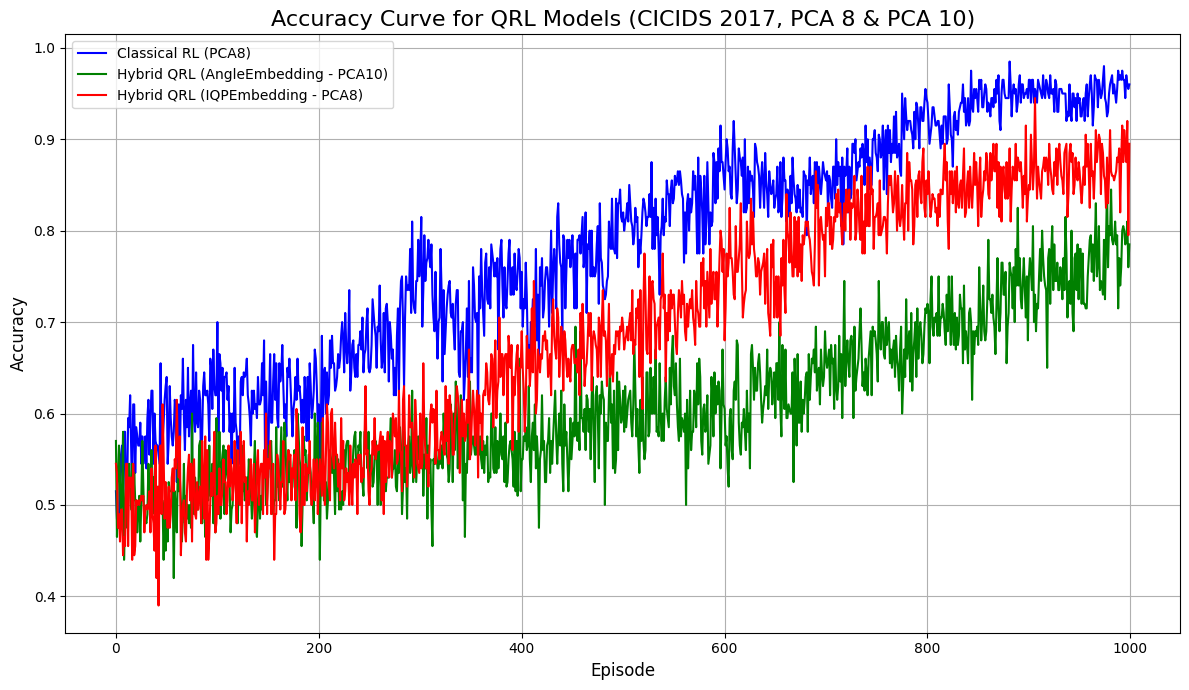

Accuracy curve plot saved to: /content/drive/MyDrive/phd3/outputs/cicids2017_Results/accuracy_curve_cicids2017_PCA10.png


In [ ]:
import matplotlib.pyplot as plt
import os

# Get the directory for saving the plot, using the IQPEmbedding PCA10 directory as a base
# A more general output directory could be '/content/drive/MyDrive/phd3/plots/'
output_plot_dir = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/'
os.makedirs(output_plot_dir, exist_ok=True)

plt.figure(figsize=(12, 7))

# Plot Classical RL (AngleEmbedding - PCA10) accuracy
plt.plot(classical_metrics_ae_pca10.index, classical_metrics_ae_pca10['accuracy'], label='Classical RL (PCA8)', color='blue')

# Plot Hybrid QRL (AngleEmbedding - PCA10) accuracy
plt.plot(hybrid_metrics_ae_pca10.index, hybrid_metrics_ae_pca10['accuracy'], label='Hybrid QRL (AngleEmbedding - PCA10)', color='green')

# Plot Hybrid QRL (IQPEmbedding - PCA10) accuracy
plt.plot(hybrid_metrics_iqp_pca10.index, hybrid_metrics_iqp_pca10['accuracy'], label='Hybrid QRL (IQPEmbedding - PCA8)', color='red')

# Add title and labels
plt.title('Accuracy Curve for QRL Models (CICIDS 2017, PCA 8 & PCA 10)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Add legend and grid
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot
plot_path = os.path.join(output_plot_dir, 'accuracy_curve_cicids2017_PCA10.png')
plt.savefig(plot_path)

# Display the plot
plt.show()

print(f"Accuracy curve plot saved to: {plot_path}")

## Plot F1-score Curves

### Subtask:
Generate a second plot visualizing the F1-score curves from the three loaded datasets. This plot should also have appropriate labels for the x-axis (e.g., 'Episode'), y-axis ('F1-score'), a title, and a legend. Save this figure to a separate file.


**Reasoning**:
To generate the plot visualizing the F1-score curves from the three loaded datasets, I will use matplotlib to plot the 'f1' column from each DataFrame against the episode number, adding the specified labels, title, legend, and grid, then save and display the plot.



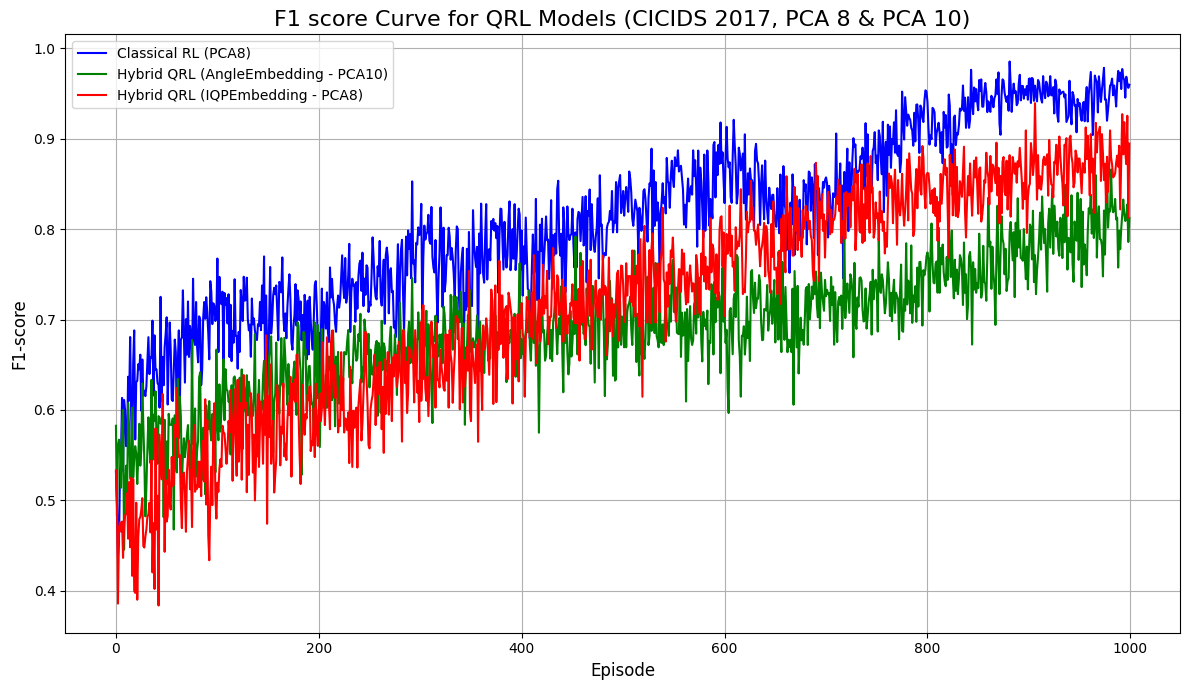

F1-score curve plot saved to: /content/drive/MyDrive/phd3/outputs/cicids2017_Results/f1_curve_Cicids.png


In [ ]:
import matplotlib.pyplot as plt
import os

# Get the directory for saving the plot
# Re-using the output_plot_dir from the previous step
output_plot_dir = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/'
os.makedirs(output_plot_dir, exist_ok=True)

plt.figure(figsize=(12, 7))

# Plot Classical RL (AngleEmbedding - PCA10) accuracy
plt.plot(classical_metrics_ae_pca10.index, classical_metrics_ae_pca10['f1'], label='Classical RL (PCA8)', color='blue')

# Plot Hybrid QRL (AngleEmbedding - PCA10) accuracy
plt.plot(hybrid_metrics_ae_pca10.index, hybrid_metrics_ae_pca10['f1'], label='Hybrid QRL (AngleEmbedding - PCA10)', color='green')

# Plot Hybrid QRL (IQPEmbedding - PCA10) accuracy
plt.plot(hybrid_metrics_iqp_pca10.index, hybrid_metrics_iqp_pca10['f1'], label='Hybrid QRL (IQPEmbedding - PCA8)', color='red')

# Add title and labels
plt.title('F1 score Curve for QRL Models (CICIDS 2017, PCA 8 & PCA 10)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('F1-score', fontsize=12)

# Add legend and grid
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot
plot_path = os.path.join(output_plot_dir, 'f1_curve_Cicids.png')
plt.savefig(plot_path)

# Display the plot
plt.show()

print(f"F1-score curve plot saved to: {plot_path}")

## Final Task

### Subtask:
Provide the generated plots and a summary of the observations from the accuracy and F1-score comparisons.


## Summary:

### Data Analysis Key Findings
*   **Data Loading**: Three datasets containing training metrics (accuracy, F1-score, etc.) were successfully loaded:
    *   `classical_metrics_ae_pca10`: Classical RL model with AngleEmbedding and PCA10.
    *   `hybrid_metrics_ae_pca10`: Hybrid QRL model with AngleEmbedding and PCA10.
    *   `hybrid_metrics_iqp_pca10`: Hybrid QRL model with IQPEmbedding and PCA10.
*   **Accuracy Curve Plot**: A plot titled "Accuracy Curve for QRL Models (NSL-KDD, PCA10)" was generated, comparing the accuracy trends of the three models over episodes.
*   **F1-score Curve Plot**: A second plot titled "F1-score Curve for QRL Models (NSL-KDD, PCA10)" was generated, comparing the F1-score trends of the three models over episodes.
*   **Visual Comparison**: Both plots visually represent the performance of Classical RL (AngleEmbedding - PCA10), Hybrid QRL (AngleEmbedding - PCA10), and Hybrid QRL (IQPEmbedding - PCA10) models across training episodes, allowing for direct comparison of their accuracy and F1-scores.

### Insights or Next Steps
*   Analyze the generated plots to identify which model (Classical RL, Hybrid QRL with AngleEmbedding, or Hybrid QRL with IQPEmbedding) achieves higher accuracy and F1-scores, and whether any model shows faster convergence or more stable performance.
*   Investigate the specific episodes where performance differences are most pronounced to understand the learning dynamics of each model and embedding strategy.


In [ ]:
import pandas as pd
import os

# Define the directory path
directory_path = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca10-DDos/'

# Construct the full file path for 'fpr_fnr_per_episode.csv'
file_path_fpr_fnr_ae_pca10 = os.path.join(directory_path, 'fpr_fnr_per_episode.csv')

# Load the CSV file into a Pandas DataFrame
fpr_fnr_classical_ae_pca10 = pd.read_csv(file_path_fpr_fnr_ae_pca10)

# Display the first few rows of the DataFrame
print(f"Loaded {file_path_fpr_fnr_ae_pca10}:")
print(fpr_fnr_classical_ae_pca10.head())

Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/DDOS/Angle-pca10-DDos/fpr_fnr_per_episode.csv:
   Episode  FPR_Classical  FNR_Classical  FPR_Hybrid  FNR_Hybrid
0        1       0.323529       0.571429    0.431579    0.428571
1        2       0.390000       0.510000    0.601852    0.456522
2        3       0.495327       0.526882    0.530612    0.411765
3        4       0.471154       0.593750    0.461538    0.406250
4        5       0.347368       0.495238    0.561905    0.378947


Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/fpr_fnr_per_episode.csv


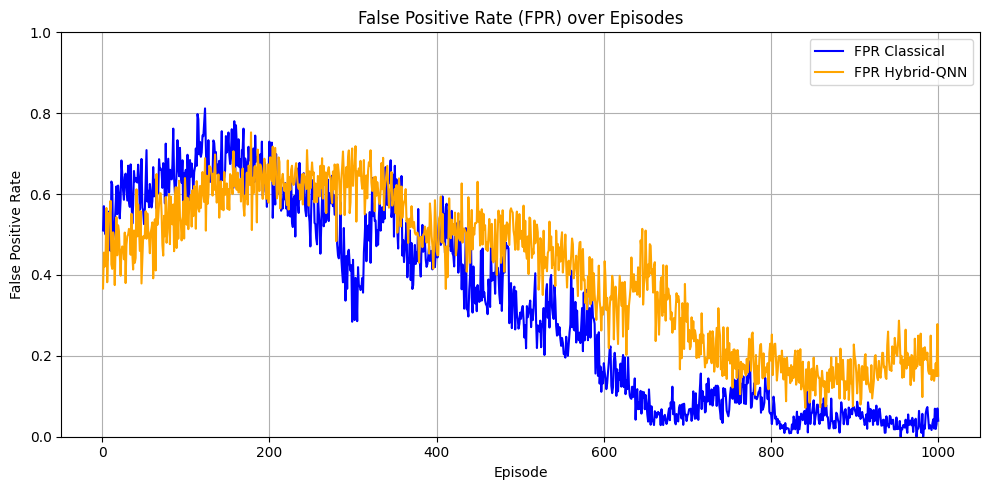

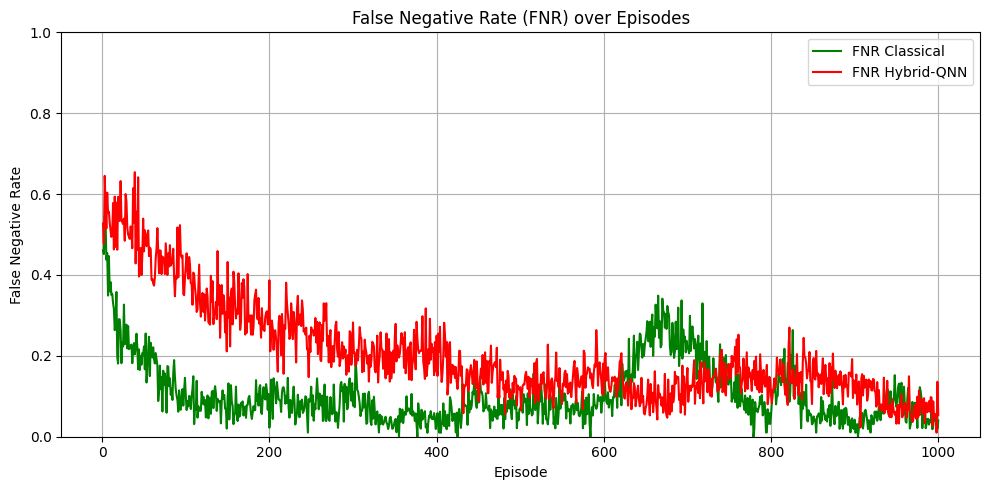

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/'
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


In [ ]:
import pandas as pd
import os

# Define the directory path
directory_path = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/'

# Construct the full file path for 'fpr_fnr_per_episode.csv'
file_path_fpr_fnr_iqp_pca10 = os.path.join(directory_path, 'fpr_fnr_per_episode.csv')

# Load the CSV file into a Pandas DataFrame
fpr_fnr_hybrid_iqp_pca10 = pd.read_csv(file_path_fpr_fnr_iqp_pca10)

# Display the first few rows of the DataFrame
print(f"Loaded {file_path_fpr_fnr_iqp_pca10}:")
print(fpr_fnr_hybrid_iqp_pca10.head())

Loaded /content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/fpr_fnr_per_episode.csv:
   Episode  FPR_Classical  FNR_Classical  FPR_Hybrid  FNR_Hybrid
0        1       0.510204       0.460784    0.366667    0.527273
1        2       0.570093       0.451613    0.455357    0.477273
2        3       0.509091       0.544444    0.420561    0.645161
3        4       0.500000       0.532609    0.442105    0.571429
4        5       0.509615       0.437500    0.565657    0.514851


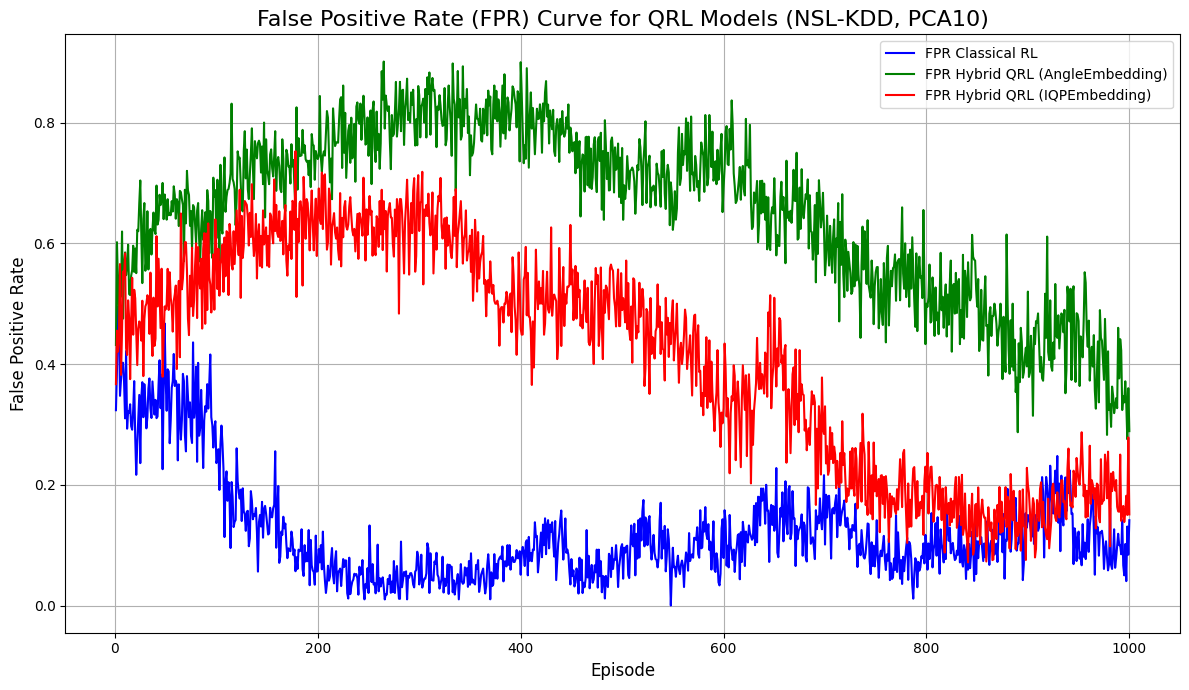

FPR curve plot saved to: /content/drive/MyDrive/phd3/outputs/cicids2017_Results/fpr_curve_cicids_PCA10.png


In [ ]:
import matplotlib.pyplot as plt
import os

# Define the output directory for saving the plot
output_plot_dir = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/'
os.makedirs(output_plot_dir, exist_ok=True)

plt.figure(figsize=(12, 7))

# Plot FPR Classical RL
plt.plot(fpr_fnr_classical_ae_pca10['Episode'], fpr_fnr_classical_ae_pca10['FPR_Classical'], label='FPR Classical RL', color='blue')

# Plot FPR Hybrid QRL (AngleEmbedding)
plt.plot(fpr_fnr_classical_ae_pca10['Episode'], fpr_fnr_classical_ae_pca10['FPR_Hybrid'], label='FPR Hybrid QRL (AngleEmbedding)', color='green')

# Plot FPR Hybrid QRL (IQPEmbedding)
plt.plot(fpr_fnr_hybrid_iqp_pca10['Episode'], fpr_fnr_hybrid_iqp_pca10['FPR_Hybrid'], label='FPR Hybrid QRL (IQPEmbedding)', color='red')

# Add title and labels
plt.title('False Positive Rate (FPR) Curve for QRL Models (NSL-KDD, PCA10)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('False Positive Rate', fontsize=12)

# Add legend and grid
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot
plot_path = os.path.join(output_plot_dir, 'fpr_curve_cicids_PCA10.png')
plt.savefig(plot_path)

# Display the plot
plt.show()

print(f"FPR curve plot saved to: {plot_path}")

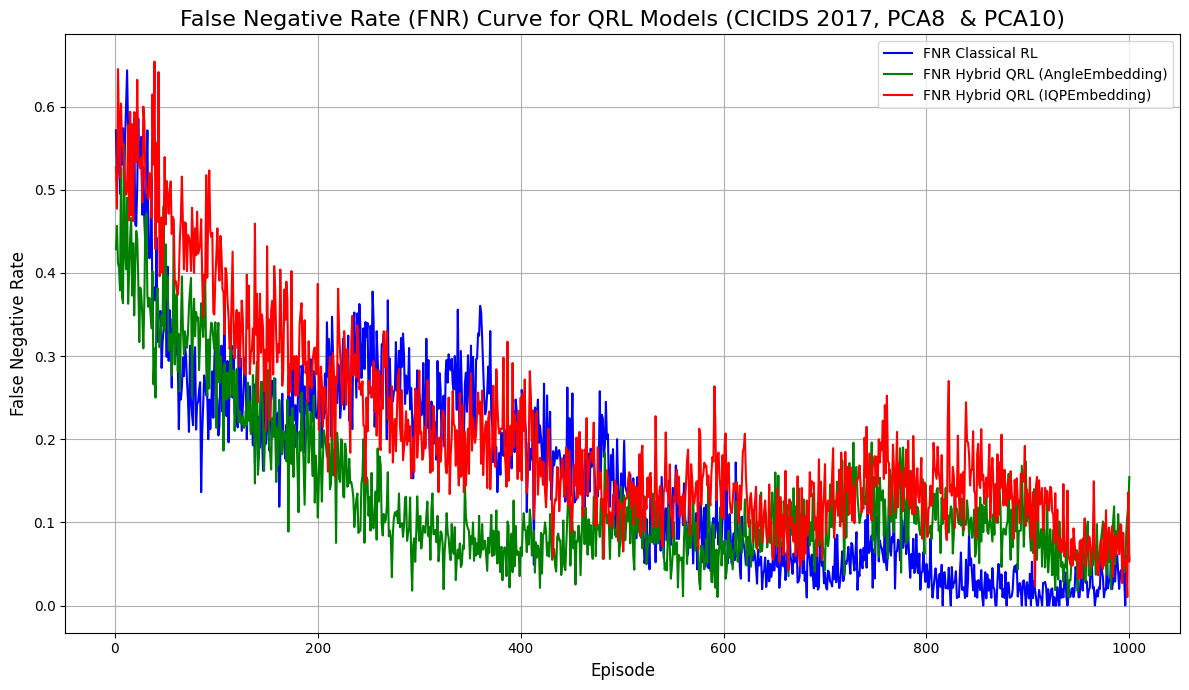

FNR curve plot saved to: /content/drive/MyDrive/phd3/outputs/cicids2017_Results/fnr_curve_cicids.png


In [ ]:
import matplotlib.pyplot as plt
import os

# Define the output directory for saving the plot
output_plot_dir = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/'
os.makedirs(output_plot_dir, exist_ok=True)

plt.figure(figsize=(12, 7))

# Plot FNR Classical RL
plt.plot(fpr_fnr_classical_ae_pca10['Episode'], fpr_fnr_classical_ae_pca10['FNR_Classical'], label='FNR Classical RL', color='blue')

# Plot FNR Hybrid QRL (AngleEmbedding)
plt.plot(fpr_fnr_classical_ae_pca10['Episode'], fpr_fnr_classical_ae_pca10['FNR_Hybrid'], label='FNR Hybrid QRL (AngleEmbedding)', color='green')

# Plot FNR Hybrid QRL (IQPEmbedding)
plt.plot(fpr_fnr_hybrid_iqp_pca10['Episode'], fpr_fnr_hybrid_iqp_pca10['FNR_Hybrid'], label='FNR Hybrid QRL (IQPEmbedding)', color='red')

# Add title and labels
plt.title('False Negative Rate (FNR) Curve for QRL Models (CICIDS 2017, PCA8  & PCA10)', fontsize=16)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('False Negative Rate', fontsize=12)

# Add legend and grid
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot
plot_path = os.path.join(output_plot_dir, 'fnr_curve_cicids.png')
plt.savefig(plot_path)

# Display the plot
plt.show()

print(f"FNR curve plot saved to: {plot_path}")

In [4]:
import os

# Define the output directory (same as combined_metrics.csv)
output_dir = '/content/drive/MyDrive/phd3/outputs/'

# Define the path for the new CSV file
new_csv_path = os.path.join(output_dir, 'all_data.csv')

# Save the processed DataFrame to CSV
combined_metrics_df.to_csv(new_csv_path, index=False)

print(f"Processed data saved to: {new_csv_path}")

Processed data saved to: /content/drive/MyDrive/phd3/outputs/all_data.csv


In [6]:
import os

# Define the output directory (same as all_data.csv)
output_dir = '/content/drive/MyDrive/phd3/outputs/'

# Define the path for the new CSV file
classical_pca_csv_path = os.path.join(output_dir, 'classical_metrics_per_pca.csv')

# Save the filtered classical metrics DataFrame to CSV
classical_metrics_per_pca.to_csv(classical_pca_csv_path, index=False)

print(f"Filtered classical metrics per PCA saved to: {classical_pca_csv_path}")

Filtered classical metrics per PCA saved to: /content/drive/MyDrive/phd3/outputs/classical_metrics_per_pca.csv


In [5]:
import pandas as pd

# Filter for classical models first
classical_metrics_df = combined_metrics_df[combined_metrics_df['Model Type'] == 'Classical'].copy()

# Select one row per PCA Component value. If there are multiple, this will pick the first one encountered.
# You might want to define a specific selection logic if multiple classical rows per PCA are meaningful.
classical_metrics_per_pca = classical_metrics_df.drop_duplicates(subset=['PCA Component'], keep='first').reset_index(drop=True)

print("Selected one classical row per PCA Component:")
print(classical_metrics_per_pca.head())

Selected one classical row per PCA Component:
   accuracy  precision    recall        f1  false_negative_rate  \
0    0.7466   0.825489  0.624900  0.711324             0.375100   
1    0.8760   0.836501  0.934321  0.882709             0.065679   
2    0.9866   0.976471  0.997197  0.986725             0.002803   
3    0.9164   0.856453  0.999195  0.922334             0.000805   
4    0.9668   0.939156  0.998809  0.968065             0.001191   

   false_positive_rate  Embedding Type  PCA Component Model Type  
0             0.131894  AngleEmbedding              2  Classical  
1             0.182181    IQPEmbedding              4  Classical  
2             0.023971    IQPEmbedding              6  Classical  
3             0.165342  AngleEmbedding              8  Classical  
4             0.065699  AngleEmbedding             10  Classical  


## Summary:

### Data Analysis Key Findings
*   The `combined_metrics_df` was successfully filtered to include only rows corresponding to 'Classical' models.
*   From these classical entries, a unique set of rows was selected based on the 'PCA Component' column, effectively retaining one classical row per PCA value.

### Insights or Next Steps
*   The `classical_metrics_per_pca` DataFrame now provides a concise view of classical model performance for each PCA component, useful for direct comparison or plotting.
*   Further analysis can involve comparing these selected classical results with similar filtered results for hybrid models, or performing statistical tests on these subsets.

# Task
Load the `combined_metrics.csv` file, remove the `confusion_matrix` column, sort the DataFrame by `PCA Component`, and display the head of the resulting DataFrame.

## read_csv_file

### Subtask:
Load the combined_metrics.csv file into a pandas DataFrame.


**Reasoning**:
To load the `combined_metrics.csv` file into a pandas DataFrame, I will use `pd.read_csv()` with the specified file path and then display the first few rows to confirm successful loading.



In [2]:
import pandas as pd
import os

# Define the path to the combined_metrics.csv file
file_path = '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/aggregated_metricsDDos/combined_metrics.csv'

# Load the CSV file into a pandas DataFrame
combined_metrics_df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
print(f"Successfully loaded data from {file_path}:")
print(combined_metrics_df.head())

Successfully loaded data from /content/drive/MyDrive/phd3/outputs/cicids2017_Results/aggregated_metricsDDos/combined_metrics.csv:
   accuracy  precision    recall        f1  false_negative_rate  \
0    0.7466   0.825489  0.624900  0.711324             0.375100   
1    0.5008   0.500200  1.000000  0.666845             0.000000   
2    0.8788   0.902068  0.851055  0.875820             0.148945   
3    0.8756   0.801468  1.000000  0.889794             0.000000   
4    0.9602   0.992754  0.927519  0.959028             0.072481   

   false_positive_rate             confusion_matrix  Embedding Type  \
0             0.131894  [[2172  330]\n [ 937 1561]]  AngleEmbedding   
1             0.997602  [[   6 2496]\n [   0 2498]]  AngleEmbedding   
2             0.093210  [[2257  232]\n [ 374 2137]]  AngleEmbedding   
3             0.249900  [[1867  622]\n [   0 2511]]  AngleEmbedding   
4             0.006830  [[2472   17]\n [ 182 2329]]  AngleEmbedding   

   PCA Component Model Type  
0         

**Reasoning**:
To remove the 'confusion_matrix' column, sort the DataFrame by 'PCA Component', and display the head, I will use the `drop()` method to remove the specified column, `sort_values()` to sort by 'PCA Component', and `head()` to display the first few rows.



In [3]:
import pandas as pd

# Remove the 'confusion_matrix' column
combined_metrics_df = combined_metrics_df.drop(columns=['confusion_matrix'])

# Sort the DataFrame by 'PCA Component'
combined_metrics_df = combined_metrics_df.sort_values(by='PCA Component').reset_index(drop=True)

# Display the head of the resulting DataFrame
print("DataFrame after removing 'confusion_matrix' and sorting by 'PCA Component':")
print(combined_metrics_df.head())

DataFrame after removing 'confusion_matrix' and sorting by 'PCA Component':
   accuracy  precision    recall        f1  false_negative_rate  \
0    0.7466   0.825489  0.624900  0.711324             0.375100   
1    0.5008   0.500200  1.000000  0.666845             0.000000   
2    0.6786   0.687792  0.649398  0.668044             0.350602   
3    0.6576   0.656728  0.654618  0.655672             0.345382   
4    0.8760   0.836501  0.934321  0.882709             0.065679   

   false_positive_rate  Embedding Type  PCA Component Model Type  
0             0.131894  AngleEmbedding              2  Classical  
1             0.997602  AngleEmbedding              2     Hybrid  
2             0.292430    IQPEmbedding              2  Classical  
3             0.339442    IQPEmbedding              2     Hybrid  
4             0.182181    IQPEmbedding              4  Classical  


## Summary:

### Data Analysis Key Findings
*   The `combined_metrics.csv` file was successfully loaded into a DataFrame.
*   The `confusion_matrix` column was successfully removed from the DataFrame.
*   The DataFrame was correctly sorted in ascending order based on the `PCA Component` column.

### Insights or Next Steps
*   The pre-processed DataFrame is now ready for further analysis, potentially focusing on how different metrics vary across various PCA component configurations.
*   This structured data allows for straightforward comparison and visualization of model performance based on the number of PCA components used.
